# Gradient verification for the 1D diffusion case with 1st order kinetics

The goal here is to verify the correctness of the adjoint state method in HYTEC by comparing the results with the demonstrator's which are considered as correct.

In [2]:
from pathlib import Path
import copy
import time
from typing import Dict
import pyrtid
import pyrtid.forward as dmfwd
import pyrtid.inverse as dminv
import hytecio

# from pyesmda.esmda
from hytecio.core import (
    AdjustableParameter,
    HytecSimulation,
    ParameterFiles,
    Observable,
    ObservationType,
)

from hytecio.job_managers import (
    FrontalHytecRunner,
    JobConfig,
    SlurmHytecRunner,
    QsubHytecRunner,
)
import hytecio.core.model as hymd
from hytecio.utils import (
    StrEnum,
    is_tool,
    get_hytec_version,
    get_mpi_version,
    indices_to_hytec_node_number,
    gen_random_ensemble,
    get_normalized_mean_from_lognormal_params,
    get_normalized_std_from_lognormal_params,
)
from hytecio.plot import plot_observed_vs_simulated
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.animation import HTMLWriter
from IPython.display import HTML
import nested_grid_plotter
from nested_grid_plotter import (
    NestedGridPlotter,
    AnimatedPlotter,
    extract_frames_from_embedded_html_animation,
    multi_imshow,
)
import numpy as np
import numpy.typing as npt
import pandas as pd
from scipy.ndimage.filters import gaussian_filter
import gstools as gs
from pyrtid.utils import NDArrayFloat, NDArrayInt

gs.config.USE_RUST = True  # Use the rust implementation of gstools

/tmp/ipykernel_1681/4074974054.py:51: DeprecationWarning: Please use `gaussian_filter` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  from scipy.ndimage.filters import gaussian_filter


- Type hints definition for numpy arrays

- Check package/software versions

In [4]:
print(f"hytecio version = {hytecio.__version__}")
print(f"nested_grid_plotter version = {nested_grid_plotter.__version__}")
print(f"pyrtid version = {pyrtid.__version__}")


class RunnerType(StrEnum):
    FRONTAL = "frontal"
    QSUB = "qsub"
    SLURM = "slurm"
    UNKNOWN = "unknown"


hytec_paths = {
    RunnerType.FRONTAL: "hytec",
    RunnerType.QSUB: "/omines/home/public/Programs/HYTEC/hytec-4.7.4",
    RunnerType.SLURM: "/cluster/GEOSCIENCES/home/acollet/hytec/svn/build/bin/Release/hytec",
}

v = ""
runner_type = RunnerType.UNKNOWN
for k, v in hytec_paths.items():
    if is_tool(v):
        runner_type = k
        break

if runner_type == RunnerType.UNKNOWN:
    raise Exception("no valid hytec command found !")

# Path or alias to the hytec binary on your local machine.
hytec_binary_path_or_alias: str = v

print(f"HYTEC version = {get_hytec_version(hytec_binary_path_or_alias)}")

mpi_binary_path_or_alias: str = {
    RunnerType.FRONTAL: "mpiexec",
    RunnerType.QSUB: "mpiexec",
    RunnerType.SLURM: "/cluster/GEOSCIENCES/home/apps/mpich/4.0.2/bin/mpiexec",
}[runner_type]

print(f"mpiexec version = {get_mpi_version(mpi_binary_path_or_alias)}")

dos2unix_binary_path_or_alias = "dos2unix"

hytecio version = 0.1.5
nested_grid_plotter version = 0.1.0
pyrtid version = 0.1.0
HYTEC version = 4.7.4-r1663
mpiexec version = 4.1.1


- Create a directory to store the exported figures

In [5]:
ipynb_path = os.path.dirname(os.path.realpath("__file__"))
fig_save_path = Path(ipynb_path, "exported_figures")
fig_save_path.mkdir(parents=True, exist_ok=True)  # make sure that the directory exists

- Define some configurations for the plots

In [6]:
# Some configs for the plots
new_rc_params = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "DejaVu Sans"],
    "font.size": 16,
    "text.usetex": False,
    "savefig.format": "svg",
    "svg.fonttype": "none",  # to store text as text, not as path
    "savefig.facecolor": "w",
    "savefig.edgecolor": "k",
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "figure.facecolor": "w",
    # "axes.facecolor": "w",
}
csfont = {"fontname": "Comic Sans MS"}
hfont = {"fontname": "Helvetica"}
plt.plot()
plt.close()  # required for the plot to update
plt.rcParams.update(new_rc_params)

## Forward problem

- Define a very simple pure diffusion - advection case in 1D.

In [7]:
nx = 40  # number of voxels along the x axis
ny = 1  # number of voxels along the y axis
dx = 10.0  # voxel dimension along the x axis
dy = 10.0  # voxel dimension along the y axis
nt = 300  # number of time steps
dt = 43200.0  # timestep in seconds
c0 = 0  # general initial cocentration
# Hydro parameters
D0 = 1e-8  # general initial diffusion coefficient [m2/s]
k0 = 1e-4  # general permeability
w0 = 0.23  # general porosity [fraction]
wdiff = 1.0  # Diffusion
wadv = 1.0  # Advection
# Chemistry parameters
c0 = 0.0  # general initial concentration [molal]
M0 = 0.001  # mineral grade [mol/kg] -> kg of water
kv = -6.9e-9  # kinetic rate,       [mol/m2/s]
moleweight = 270.0  # molar weight [g/mol]
surface = 500  # cm2/g
As = moleweight * surface / 1e4  # specific area [m2/mol]
logK = 3.2
Ks = 1.0 / pow(10, logK)  # solubility constant [no unit]
wmin = 1.0  # Mineral dissolution

# Values for the x axis ()meters
x_positions_in_meters: NDArrayFloat = np.arange(nx) * dx + dx / 2

- Five observation wells

In [8]:
production_locations = [12, 28]
injection_locations = [4, 20, 36]

The mineral grades are defined in [mol/kg]. We calculate the conversion factor to obtain ppm and perform easier mass balances.

ConvU: parameter for converting the mineral content in [mol/kg] to metal grade in [ppm]. Note that the ConvU parameter is specific to the Uranium carrier phase: here Uraninite.

$C_{Uraninite}[\frac{mol}{kg}] = convU \times T_{Uranium}[ppm]$


and


$conv_u = \frac{1.023 \times density_{rock}}{238*porosity_{rock} \times 1000}$

Note the 1.023 is the conversion factor from molar mass to molal mass in CHESS.

In [9]:
conv_u: float = 1.023 * 1.63 / (238.0 * w0 * 1000)
print(f"conv_u = {conv_u:.4e}")

conv_u = 3.0462e-05


- Create an initial gaussian spatial distribution for the mineral

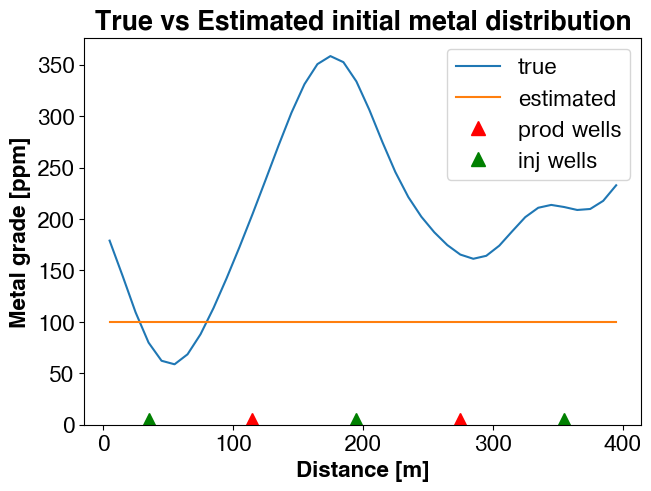

In [10]:
# Create a Gaussian Covariance Model just for the example
# To vary the results, change the seed :)
seed = 6

min_val = 10 * conv_u  # 10 ppm
max_val = 500 * conv_u  # 500 ppm
# Compute the mean and the standard deviation that the distribution should have so that
# <99% of the values are between min and max ~ 6 sigmas
mean = (max_val + min_val) / 2
stdev = (max_val - min_val) / 3 / 2  # std ~ 1/6 of the distribution interval
len_scale = 5

m_init_true = gen_random_ensemble(
    model=gs.covmodel.Gaussian,
    n_ensemble=1,
    var=stdev**2,
    len_scale=len_scale,
    mean=mean,
    nx=nx,
    ny=ny,
    seed=seed,
)[0, :, :, 0]


# Initial estimate = an homogeneous value
m_init_estimate = np.ones((nx, ny)) * 100 * conv_u  # 50 ppm

plotter = NestedGridPlotter()
ax = plotter.ax_dict["ax1-1"]

ax.set_xlabel("Distance [m]", fontweight="bold")
ax.set_ylabel("Metal grade [ppm]", fontweight="bold")
ax.set_ylim(0.0, np.max((m_init_estimate, m_init_true)) / conv_u * 1.05)
ax.set_title("True vs Estimated initial metal distribution", fontweight="bold")
plotter.fig.set_facecolor("w")


ax.plot(x_positions_in_meters, m_init_true / conv_u, label="true")
ax.plot(x_positions_in_meters, m_init_estimate / conv_u, label="estimated")

# Add some vertical lines to indicate the well
for well_pos in production_locations:
    ax.plot(
        well_pos * dx - dx / 2,
        5.0,
        label="prod wells",
        marker="^",
        markersize=10,
        c="r",
        linestyle="none",
    )

for well_pos in injection_locations:
    ax.plot(
        well_pos * dx - dx / 2,
        5.0,
        label="inj wells",
        marker="^",
        markersize=10,
        c="g",
        linestyle="none",
    )

plotter.add_axis_legend("ax1-1")

fname = "true_vs_estimated_initial_mineral_field"
for format in ["png", "pdf"]:
    plotter.fig.savefig(fig_save_path.joinpath(f"{fname}.{format}"), format=format)

- Note: The initial concentration is null.

- Create the flowrates for the wells: 12 m3/h decreasing following an exponential... for the producers with a balanced injection (2 m3/h per associated cell for the injectors).

In [11]:
def gen_flowrates(amplitude: float, coef: float, nt: int, dt: float) -> np.ndarray:
    """Generate flowrates with a given amplitude and decrease coefficient.

    Parameters
    ----------
    amplitude : float
        Amplitude in m3/h.
    coef : float
    dt : float
        Timesteps.

    Returns
    -------
    np.ndarray
        The flowrates.
    """
    return amplitude * np.exp(coef * np.arange(nt) * dt)

- Generate a flowrates with an initial amplitude at 1 m3/h and plot it

Text(0.5, 0, 'time [d]')

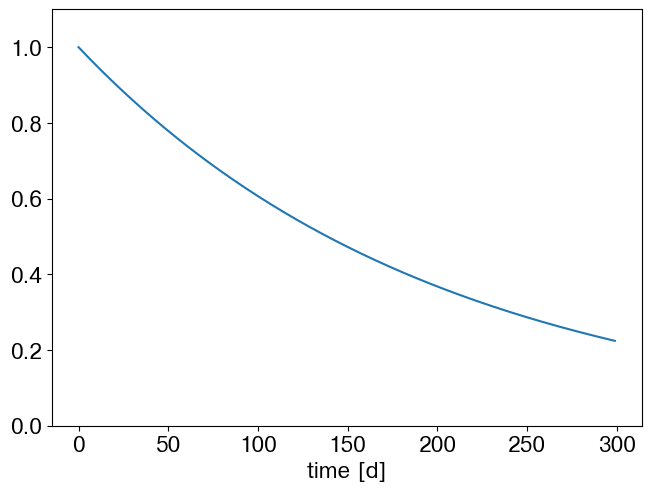

In [12]:
flowrates = gen_flowrates(1.0, -0.005, nt, dt=1.0)  # m/h

plt.plot(np.arange(nt), flowrates)
plt.ylim(0.0, 1.10)
plt.xlabel("time [d]")

### Forward problem in demonstrator

In [13]:
# We define a function to easily generate a model.
def create_base_model() -> RTModel:
    return RTModel(
        nx,
        ny,
        dx,
        dy,
        nt,
        dt,
        c0,
        D0,
        k0,
        w0,
        M0,
        kv,
        As,
        Ks,
        wdiff=wdiff,
        wadv=wadv,
        wmin=wmin,
    )

NameError: name 'RTModel' is not defined

- Create two models

In [ ]:
model_true = create_base_model()
model_estimate = create_base_model()
# Exact diffusion
model_true.m_init = m_init_true
# Estimated diffusion
model_estimate.m_init = m_init_estimate

- Run the models

In [ ]:
solver_true = RTSolver(model_true)
solver_true.solve()

solver_estimate = RTSolver(model_estimate)
solver_estimate.solve()

### Forward problem definition in HYTEC

- Define a runner

In [ ]:
if runner_type == RunnerType.FRONTAL:
    runner = FrontalHytecRunner(
        hytec_binary_path_or_alias=hytec_binary_path_or_alias,
        mpi_binary_path_or_alias=mpi_binary_path_or_alias,
        nb_cpu=2,
        freq_checks_is_simu_over_sec=5,
    )
elif runner_type == RunnerType.SLURM:
    job_config = JobConfig(
        hytec_binary_path_or_alias=hytec_binary_path_or_alias,
        nb_nodes=1,
        ncpus=2,
        queue="geo-cpu",
        mpi_binary_path_or_alias=mpi_binary_path_or_alias,
        dos2unix_binary_path_or_alias=dos2unix_binary_path_or_alias,
    )
    runner = SlurmHytecRunner(
        job_config=job_config,
        freq_checks_is_simu_over_sec=5,
    )
elif runner_type == RunnerType.QSUB:
    job_config = JobConfig(
        hytec_binary_path_or_alias=hytec_binary_path_or_alias,
        nb_nodes=1,
        ncpus=2,
        queue="Omines_cpu",
        mpi_binary_path_or_alias=mpi_binary_path_or_alias,
        dos2unix_binary_path_or_alias=dos2unix_binary_path_or_alias,
    )
    runner = QsubHytecRunner(
        job_config=job_config,
        freq_checks_is_simu_over_sec=5,
    )
else:
    raise Exception("Could not created runner")

- Create an empty simulation in a non existing folder

In [ ]:
simu_base = HytecSimulation("simu_base", Path.cwd().joinpath("simu_base"))

- Add a TDB file

In [ ]:
# Add a TDB file
simu_base.link_tdb("./../../../../../TDB/chess.tdb")  # This is relative to the htc file

- Define the output format

In [ ]:
simu_base.model.add_sub_item(hymd.OutputFormat("vtk"))

- Hydrodynamic model and its parameters definition

In [ ]:
hmodel = hymd.HydrodynamicModel(
    hymd.FlowRegime("stationary"),
    hymd.Porosity(w0),
    hymd.Permeability(k0, units="m/s"),
    hymd.DiffusionCoefficient(D0, units="m2/s"),
    hymd.Head(0.0, "m"),
    # hymd.CrankNicholson(1.0)
)
simu_base.model.add_sub_item(hmodel)

- Geochemical unit definition

In [ ]:
chmodel = hymd.GeochemicalModel(hymd.Report("full"), hymd.Redox("disabled"))
# Define a geochem unit
base_unit = hymd.GeochemicalUnit("chem_base")

species = "T_Cinet"
# Set concentrations
base_unit.add_sub_item(hymd.Concentration(species, c0, units="molal"))
base_unit.add_sub_item(
    hymd.Mineral(
        f"Min_{species}",
        M0,
        grade_units="mol/kg",
        surface=As,
        surface_units="m2/mol",
    )
)

inj_unit = hymd.GeochemicalUnit("injected_solution")
inj_unit.add_sub_item(hymd.Concentration(species, c0, units="molal"))

# define tracer
chmodel.add_sub_item(
    hymd.Define("basis", species, hymd.MoleWeight(moleweight, units="g/mol"))
)

# define associated mineral
chmodel.add_sub_item(
    hymd.Define(
        "mineral",
        f"Min_{species}",
        hymd.Composition(f"1 {species}"),
        hymd.LogK(logK),
        hymd.Surface(surface, units="cm2/g"),
        hymd.Kinetics(
            hymd.Rate(kv, units="mol/m2/s"),
            hymd.Area(f"Min_{species}"),
            hymd.Yterm(hymd.Species(f"Min_{species}")),
        ),
    )
)
# exclude
chmodel.add_sub_item(hymd.Exclude(("minerals", "colloids", "gases")))

# Add the units to the geochemical model
chmodel.add_sub_item(base_unit)
chmodel.add_sub_item(inj_unit)

# Add to the main model
simu_base.model.add_sub_item(chmodel)

- Geometry definition

In [ ]:
gmodel = hymd.GeometryModel(
    hymd.GridRegime("rectangle"), hymd.Domain(f"{nx*dx},{nx} {ny*dy},{ny}")
)
dzone = hymd.Zone("domain", hymd.Geometry("domain"), hymd.Geochemistry("chem_base"))
gmodel.add_sub_item(dzone)
simu_base.model.add_sub_item(gmodel)

- Boundary model definition

In [ ]:
flc = hymd.FlowCondition("constant-head at 0 m")
bmodel = hymd.BoundaryModel(
    hymd.Boundary("border_left", hymd.Coordinates(f"0,0, 0,{ny*dy}", units="m"), flc),
    hymd.Boundary(
        "border_right", hymd.Coordinates(f"{nx*dx},{ny*dy}, {nx*dx},0", units="m"), flc
    ),
)
simu_base.model.add_sub_item(bmodel)

- Time discretization

In [ ]:
tmodel = hymd.TimeDiscretizationModel(
    hymd.Duration(nt * dt, units="s"),
    hymd.TimeStep(
        hymd.Variable(
            hymd.StartValue(dt, "s"), hymd.Maximum(dt, "s"), hymd.CourantFactor(20.0)
        ),
    ),
)
simu_base.model.add_sub_item(tmodel)

- Sampling definition

In [ ]:
smodel = hymd.SamplingModel(
    hymd.GridSampling(nt),
    hymd.Select("time", units="s"),
    hymd.Select("node-number"),
    hymd.Select("flowrate", units="m/s"),
    hymd.Select("permeability", units="m/s"),
    hymd.Select("head", units="m"),
    hymd.Select("porosity"),
    hymd.Select("Min_T_Cinet", units="mol/kg"),
    hymd.Select("T_Cinet", units="mol/kg"),
)
simu_base.model.add_sub_item(smodel)

- Create the injection/pumping file: 1 column per well + 1 column for the time (days)

In [ ]:
src_term_path = Path.cwd().joinpath("source_terms.dat")
src_term_data: NDArrayFloat = np.zeros(
    (nt, len(injection_locations) + len(production_locations) + 1)
)
src_term_data[:, 0] = np.arange(stop=nt + 1, start=1)

- Create one zone per well with the correct flowrates: negative for producers and positive for injectors.

In [ ]:
# 1) Add the producer wells
count_prod: int = 0  # to avoid unbounded values in the next loop
for count_prod, ix in enumerate(production_locations):
    name = f"producer_{ix}"
    zone = hymd.Zone(name)
    zone.add_sub_item(
        hymd.Geometry(
            f"rectangle {(ix + 0.5) * dx},{0.5 * dy}, {dx},{dy}",
            units="m",
        )
    )
    zone.add_sub_item(hymd.Geochemistry(base_unit.name))
    zone.add_sub_item(hymd.GlobalFlux(name))
    zone.add_sub_item(hymd.Source(-8, units="m3/h"))
    zone.add_sub_item(
        hymd.Modify(
            "$1",
            hymd.Source(
                f"${count_prod+2}",
                units=f"m3/h using {base_unit.name} from {src_term_path}",
            ),
            time_units="d",
        )
    )
    simu_base.model.get_sub_model(hymd.GeometryModel).add_sub_item(zone)
    # Update the src_terms file -> 2 m3/h for a producer
    src_term_data[:, count_prod + 1] = -flowrates * 8

n_prod_linked_list = [1, 2, 1]

# 2) Add the injector wells
for count_inj, ix in enumerate(injection_locations):
    name = f"injector_{ix}"
    zone = hymd.Zone(name)
    zone.add_sub_item(
        hymd.Geometry(
            f"rectangle {(ix + 0.5) * dx},{0.5 * dy}, {dx},{dy}",
            units="m",
        )
    )
    zone.add_sub_item(hymd.Geochemistry(base_unit.name))
    zone.add_sub_item(hymd.GlobalFlux(name))
    zone.add_sub_item(
        hymd.Source(f"{n_prod_linked_list[count_inj] * 4} m3/h using injected_solution")
    )
    zone.add_sub_item(
        hymd.Modify(
            "$1",
            hymd.Source(
                f"${count_prod + count_inj +3}",
                units=f"m3/h using {base_unit.name} from {src_term_path}",
            ),
            time_units="d",
        )
    )
    simu_base.model.get_sub_model(hymd.GeometryModel).add_sub_item(zone)

    src_term_data[:, count_prod + count_inj + 2] = (
        +flowrates * n_prod_linked_list[count_inj] * 4
    )

# 3) Add the src_data_file (need to write and read the file... which is a bit stupid...)
# Register the source data file
simu_base.register_modifiy_src_file(src_term_path, src_term_data, fmt="%.3f")

- Create two models from this base simulation

In [ ]:
simu_true = copy.deepcopy(simu_base)
simu_true.update_root_and_name(new_root="simu_true", new_name="simu_true")
simu_estimate = copy.deepcopy(simu_base)
simu_estimate.update_root_and_name(new_root="simu_estimate", new_name="simu_estimate")

- Add the mineral fields to the simulations

In [ ]:
index: NDArrayFloat = np.arange(nx)

# True
data_true = pd.DataFrame(
    data={
        "node-number": index,
        # x and y are cell centers
        "x": (index % nx) * dx + dx / 2,
        "Min_T_Cinet": m_init_true.ravel(),
        "Min_T_Cinet2": m_init_true.ravel(),
    },  # need to flatten the parameter
    index=index,
)
simu_true.add_param_file_data(ParameterFiles.MINERALS, data_true)

# Estimated
data_estimated = pd.DataFrame(
    data={
        "node-number": index,
        # x and y are cell centers
        "x": (index % nx) * dx + dx / 2,
        "Min_T_Cinet": m_init_estimate.ravel(),
        "Min_T_Cinet2": m_init_estimate.ravel(),
    },  # need to flatten the parameter
    index=index,
)
simu_estimate.add_param_file_data(ParameterFiles.MINERALS, data_estimated)

- Checking the hydro parameters have been correctly set-up

In [ ]:
simu_true.handlers.minerals.data

,node-number,x,Min_T_Cinet,Min_T_Cinet2
0,0,5.0,0.005453,0.005453
1,1,15.0,0.004410,0.004410
2,2,25.0,0.003330,0.003330
3,3,35.0,0.002432,0.002432
4,4,45.0,0.001894,0.001894
5,5,55.0,0.001790,0.001790
6,6,65.0,0.002086,0.002086
7,7,75.0,0.002679,0.002679
8,8,85.0,0.003457,0.003457
9,9,95.0,0.004332,0.004332


In [ ]:
simu_estimate.handlers.minerals.data

,node-number,x,Min_T_Cinet,Min_T_Cinet2
0,0,5.0,0.003046,0.003046
1,1,15.0,0.003046,0.003046
2,2,25.0,0.003046,0.003046
3,3,35.0,0.003046,0.003046
4,4,45.0,0.003046,0.003046
5,5,55.0,0.003046,0.003046
6,6,65.0,0.003046,0.003046
7,7,75.0,0.003046,0.003046
8,8,85.0,0.003046,0.003046
9,9,95.0,0.003046,0.003046


In [ ]:
simu_true.write_input_files()
simu_estimate.write_input_files()
runner.run(simu_true)
runner.run(simu_estimate)

The job is over ! Elapsed time = 0:00:02.939985
The job is over ! Elapsed time = 0:00:03.531425


True

### Comparison between hytec and the demonstrator for the forward problem

- Reading the results for the true diffusion simulation

In [ ]:
simu_true.read_hytec_results()
simu_true.handlers.results.grid_res_columns

['timestep',
 'Zones',
 'time [s]',
 'node-number [mol/kg]',
 'flowrate [m/s]',
 'permeability [m/s]',
 'head [m]',
 'porosity []',
 'Min_T_Cinet [mol/kg]',
 'T_Cinet [mol/kg]',
 'x-distance']

In [ ]:
fwd_conc_true_hytec = simu_true.handlers.results.extract_field_from_grid_res(
    field="T_Cinet [mol/kg]", nx=nx
)
fwd_min_true_hytec = simu_true.handlers.results.extract_field_from_grid_res(
    field="Min_T_Cinet [mol/kg]", nx=nx
)
# Getting sample time. The unit is the same than the one defined for the simulation duration in the htc
flux_sample_times = simu_true.handlers.results.get_sample_times_from_grid_res()

- Reading the results for the estimated diffusion simulation

In [ ]:
simu_estimate.read_hytec_results()
simu_estimate.handlers.results.grid_res_columns

['timestep',
 'Zones',
 'time [s]',
 'node-number [mol/kg]',
 'flowrate [m/s]',
 'permeability [m/s]',
 'head [m]',
 'porosity []',
 'Min_T_Cinet [mol/kg]',
 'T_Cinet [mol/kg]',
 'x-distance']

In [ ]:
# Get the results on a 3D grid with the last dimension as time step
fwd_conc_estimate_hytec = simu_estimate.handlers.results.extract_field_from_grid_res(
    field="T_Cinet [mol/kg]", nx=nx
)
fwd_min_estimate_hytec = simu_estimate.handlers.results.extract_field_from_grid_res(
    field="Min_T_Cinet [mol/kg]", nx=nx
)

- Top view of the forward concentrations

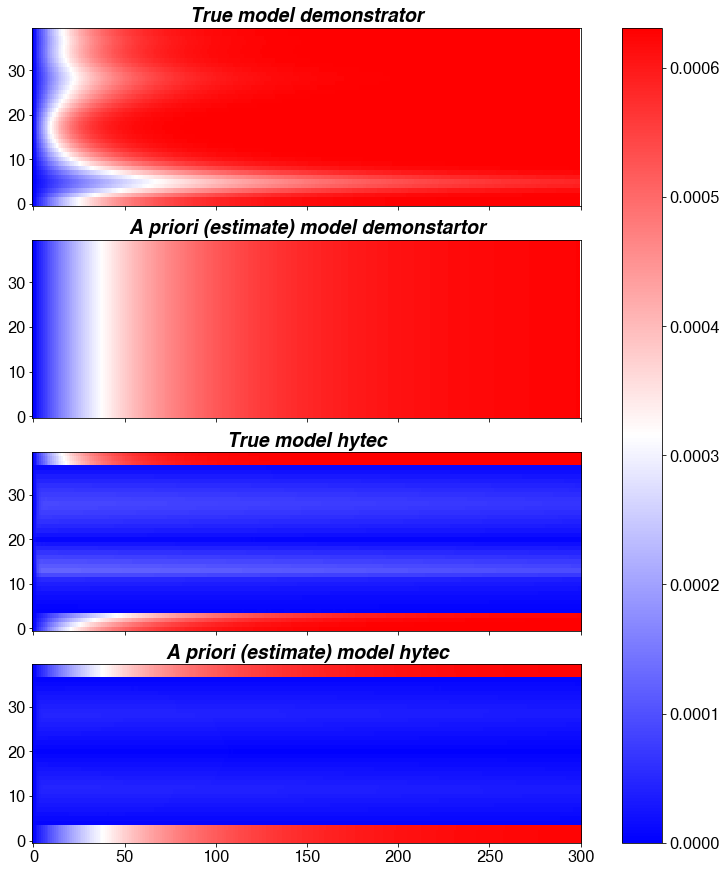

In [ ]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (10, 12)},
    subplots_mosaic_params={
        "fig0": dict(
            mosaic=[["ax1-1"], ["ax2-1"], ["ax3-1"], ["ax4-1"]],
            sharey=True,
            sharex=True,
        )
    },
)

multi_imshow(
    axes=list(plotter.ax_dict.values()),
    fig=plotter.fig,
    data={
        "True model demonstrator": solver_true.model.fwd_conc[:, 0, :].T,
        "A priori (estimate) model demonstartor": solver_estimate.model.fwd_conc[
            :, 0, :
        ].T,
        "True model hytec": fwd_conc_true_hytec[:, 0, 0, :].T,
        "A priori (estimate) model hytec": fwd_conc_estimate_hytec[:, 0, 0, :].T,
    },
)

fname = "tracer_concentration_true_vs_estimate_map"
for format in ["png", "pdf"]:
    plotter.fig.savefig(fig_save_path.joinpath(f"{fname}.{format}"), format=format)

- Forward variables at the producer locations

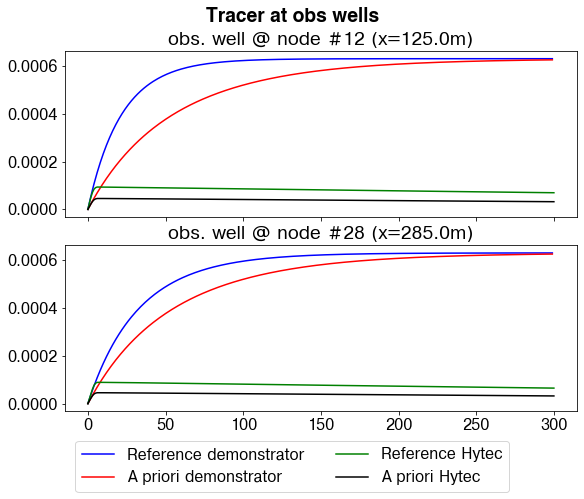

In [ ]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (8, 6)},
    subplots_mosaic_params={
        "fig0": dict(
            mosaic=[["ax1-1"], ["ax2-1"]],
            sharey=False,
            sharex=True,
        )
    },
)

for i, node_id in enumerate(production_locations):
    ax = plotter.get_axis(f"ax{i + 1}-1")
    x = (node_id + 0.5) * model_true.dx
    obs_well_name = f"obs. well @ node #{node_id} (x={x}m)"

    ax.set_title(obs_well_name)
    ax.plot(
        solver_true.model.fwd_conc[node_id, 0, :], label="Reference demonstrator", c="b"
    )
    ax.plot(
        solver_estimate.model.fwd_conc[node_id, 0, :],
        label="A priori demonstrator",
        c="r",
    )
    ax.plot(fwd_conc_true_hytec[node_id, 0, 0, :], label="Reference Hytec", c="g")
    ax.plot(fwd_conc_estimate_hytec[node_id, 0, 0, :], label="A priori Hytec", c="k")

plotter.fig.suptitle("Tracer at obs wells", fontweight="bold")
plotter.add_fig_legend(ncol=2, bbox_y_shift=-0.02)

fname = "tracer_concentration_true_vs_estimate_at_obs_1D"
for format in ["png", "pdf"]:
    plotter.fig.savefig(fig_save_path.joinpath(f"{fname}.{format}"), format=format)

- Animation of the tracer at the producer locations

In [ ]:
plotter = AnimatedPlotter(
    fig_params={"constrained_layout": True, "figsize": (12, 10)},
    subfigs_params={"nrows": 2},
    subplots_mosaic_params={
        "fig0": dict(mosaic=[["ax1-1", "ax1-2"]], sharey=True, sharex=True),
        "fig1": dict(mosaic=[["ax2-1", "ax2-2"]], sharey=True, sharex=True),
    },
)

# Static plot
x = (np.arange(nx) + 0.5) * dx
plotter.get_axis("ax1-1").plot(x, model_true.c_init * 1e3, c="red")
plotter.get_axis("ax1-2").plot(x, model_true.c_init * 1e3, c="red")
plotter.get_axis("ax2-2").plot(x, fwd_min_true_hytec[:, 0, 0, 0] / conv_u, c="red")
plotter.get_axis("ax2-2").plot(x, fwd_min_true_hytec[:, 0, 0, 0] / conv_u, c="red")

# Animated plot
nb_frames = 30

plotter.animated_multi_plot(
    ax_name="ax1-1",
    data={
        "True": {
            "x": x,
            "y": fwd_conc_true_hytec[:, 0, 0, :] * 1e3,
            "kwargs": {"c": "blue"},
        },
        "Estimated": {
            "x": x,
            "y": fwd_conc_estimate_hytec[:, 0, 0, :] * 1e3,
            "kwargs": {"c": "green", "linestyle": "--"},
        },
    },
    nb_frames=nb_frames,
    title="HYTEC conc",
    xlabel="Node #",
    ylabel="[mmol/kg]",
)

plotter.animated_multi_plot(
    ax_name="ax1-2",
    data={
        "True": {
            "x": x,
            "y": solver_true.model.fwd_conc[:, 0, :] * 1e3,
            "kwargs": {"c": "blue"},
        },
        "Estimated": {
            "x": x,
            "y": solver_estimate.model.fwd_conc[:, 0, :] * 1e3,
            "kwargs": {"c": "green", "linestyle": "--"},
        },
    },
    nb_frames=nb_frames,
    title="Demonstrator conc",
    xlabel="Node #",
)

plotter.animated_multi_plot(
    ax_name="ax2-1",
    data={
        "True": {
            "x": x,
            "y": fwd_min_true_hytec[:, 0, 0, :] / conv_u,
            "kwargs": {"c": "blue"},
        },
        "Estimated": {
            "x": x,
            "y": fwd_min_estimate_hytec[:, 0, 0, :] / conv_u,
            "kwargs": {"c": "green", "linestyle": "--"},
        },
    },
    nb_frames=nb_frames,
    title="HYTEC min",
    xlabel="Node #",
    ylabel="[ppm]",
)

plotter.animated_multi_plot(
    ax_name="ax2-2",
    data={
        "True": {
            "x": x,
            "y": solver_true.model.fwd_min[:, 0, :] / conv_u,
            "kwargs": {"c": "blue"},
        },
        "Estimated": {
            "x": x,
            "y": solver_estimate.model.fwd_min[:, 0, :] / conv_u,
            "kwargs": {"c": "green", "linestyle": "--"},
        },
    },
    nb_frames=nb_frames,
    title="Demonstrator min",
    xlabel="X (m)",
)

for ax_name in ["ax1-1", "ax1-2"]:
    # Add some vertical lines to indicate the well
    for well_pos in production_locations:
        plotter.get_axis(ax_name).plot(
            (well_pos + 1) * dx
            - dx / 2,  # Well pos + 1 because of indexing that starts at zero
            0.0,
            label="prod wells",
            marker="^",
            markersize=10,
            c="r",
            linestyle="none",
        )

    for well_pos in injection_locations:
        plotter.get_axis(ax_name).plot(
            (well_pos + 1) * dx - dx / 2,
            0.0,
            label="inj wells",
            marker="^",
            markersize=10,
            c="g",
            linestyle="none",
        )

    plotter.add_axis_legend(ax_name)

plotter.ax_dict["ax2-1"].set_ylim(0, plotter.ax_dict["ax2-1"].get_ylim()[1])

plotter.close()
plotter.animate(nb_frames=nb_frames)
# Save the animation locally on the computer
fname_html = fig_save_path.joinpath("true_vs_estimate_conc_animation.html")
writer = HTMLWriter(fps=5, embed_frames=True)
writer.frame_format = "svg"  # Ensure svg format
plotter.animation.save(fname_html, writer=writer)

# Extract the svg from the html file (for animation in Latex)
extract_frames_from_embedded_html_animation(fname_html)

# Display the animation
HTML(fname_html.read_text())

- Plot the heads

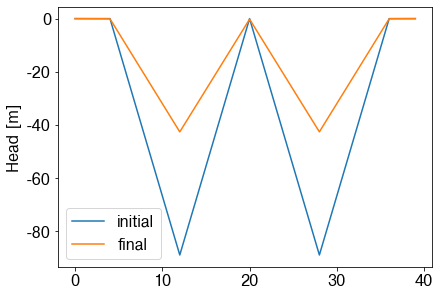

In [ ]:
fwd_heads_true_hytec = simu_true.handlers.results.extract_field_from_grid_res(
    field="head [m]", nx=nx
)

plt.plot(fwd_heads_true_hytec[:, 0, 0, 0], label="initial")
plt.plot(fwd_heads_true_hytec[:, 0, 0, -1], label="final")
plt.ylabel("Head [m]")
plt.legend()

plt.savefig(fig_save_path.joinpath("Heads in forward.png"))

- Plot the darcy velocities

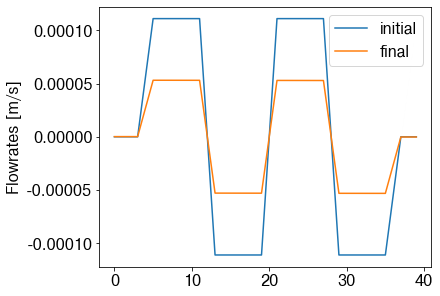

In [ ]:
fwd_darcy_true_hytec = simu_true.handlers.results.extract_field_from_grid_res(
    field="flowrate [m/s]", nx=nx
)

plt.plot(fwd_darcy_true_hytec[:, 0, 0, 0], label="initial")
plt.plot(fwd_darcy_true_hytec[:, 0, 0, -1], label="final")
plt.ylabel("Flowrates [m/s]")
plt.legend()

plt.savefig(fig_save_path.joinpath("Flowrates in forward.png"))

## Inversion

- Create a function to add some noise to the observations

In [ ]:
noise_std = 5e-6  # This is an absolute value
rng = np.random.default_rng(2021)


def make_noisy(x: NDArrayFloat) -> NDArrayFloat:
    """Return the input with some added white noise.

    Note
    ----
    The parameters are hardcoded to be consistent in the notebook.
    Change the function directly.
    """
    mean_noise = 0.0  # mean
    return x + rng.normal(mean_noise, noise_std, x.shape)

- Check the intensity of the noise

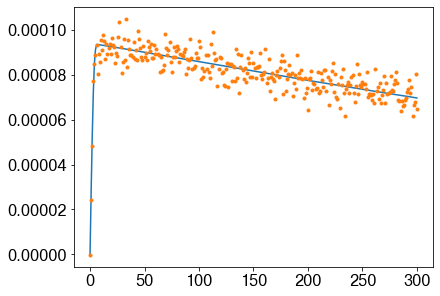

In [ ]:
node_id = production_locations[0]
plt.figure(facecolor="w")
plt.plot(fwd_conc_true_hytec[node_id, 0, 0, :])
plt.plot(
    make_noisy(fwd_conc_true_hytec[node_id, 0, 0, :]), marker=".", linestyle="none"
)

### Demonstrator


In [ ]:
# Configure an inversion
solver_config = ScipySolverConfig(
    is_check_gradient=False,
    is_use_adjoint=True,
)


def inverse_function(x: NDArrayFloat) -> NDArrayFloat:
    """Return 1/x."""
    return 1 / x


param = PyrtidAdjustableParameter(
    name=PyrtidParameterName.INITIAL_MINERAL_GRADE,
    lbound=0.0,
    ubound=600.0 * conv_u,
)

from typing import Dict  # Just for linting

observables: Dict[int, PyrtidObservable] = {}
for node_id in production_locations:
    vals = make_noisy(solver_true.model.fwd_conc[node_id, 0, :])
    timesteps = np.arange(vals.shape[0])

    observables[node_id] = PyrtidObservable(
        state_variable="tracer",
        location=(slice(node_id, node_id + 1, 1), slice(None)),
        timesteps=timesteps,
        values=vals,
        uncertainties=noise_std,
    )

# Create an executor
executor: ScipyInversionExecutor = ScipyInversionExecutor(
    model_estimate,
    parameters_to_adjust=[param],
    observables=list(observables.values()),
    solver_config=solver_config,
)

# Compute the gradient both by finite difference and adjoint method
is_grad_ok = executor.is_gradient_correct(
    param,
    list(observables.values()),
)
print("Is the gradient correct: ", is_grad_ok)

Is the gradient correct:  True


### HYTEC

In [ ]:
# 1) Copy the base simulation
simu_inverse = copy.deepcopy(simu_estimate)
simu_inverse.update_root_and_name(new_root="simu_inverse", new_name="simu_inverse")

# 2) Add the observation wells
for count, ix in enumerate(production_locations):
    x = (ix + 0.5) * model_true.dx
    zone_name = f"producer_{ix}"
    # zone = simu_inverse.model.get_sub_model(hymd.GeometryModel).get_zone(name)

    vals = make_noisy(fwd_conc_true_hytec[ix, 0, 0, :])

    # Add the observables for the area
    obs = Observable(
        zone_name=zone.name,
        state_variable=species,
        units="mol/kg",
        timesteps=flux_sample_times,
        time_units="s",
        obs_type=ObservationType.GRID,
        values=vals,
        uncertainties=np.ones(vals.size) * noise_std,
        node_numbers=np.ones(vals.size) * ix,
    )
    simu_inverse.register_observable(
        zone_name, obs, obs_file_path=f"observables/{zone_name}_{species}_o.dat"
    )

# 3) Update the htc file with some options
inv_model = hymd.InverseModel(
    hymd.OptimizationStatus("enabled"),
    hymd.OptimizationSolverConfig(
        "lbfgsb", hymd.AdjointState("enabled"), hymd.FdGradientCheck("initial")
    ),
    hymd.AdjustedParameterConfig(
        "Min_T_Cinet",
        hymd.Lbound(0.0, units="mol/kg"),
        hymd.Ubound(600.0 * conv_u, units="mol/kg"),
        phase="mineral",
    ),
)
simu_inverse.model.add_sub_item(inv_model)

# number of samples on the adjoint variables
simu_inverse.model.get_sub_model(hymd.SamplingModel).add_sub_item(
    hymd.AdjointGridSampling(nt)
)

# 4)Write the input files
simu_inverse.write_input_files()

runner.run(simu_inverse)

# 7) Read results
simu_inverse.read_hytec_results()  # This fails if not results have been written

The job is over ! Elapsed time = 0:04:36.491777


In [ ]:
simu_inverse.read_hytec_results()

- Plot the head field (to be sure it has been correctly reinitialized)

(40, 1, 1, 301)


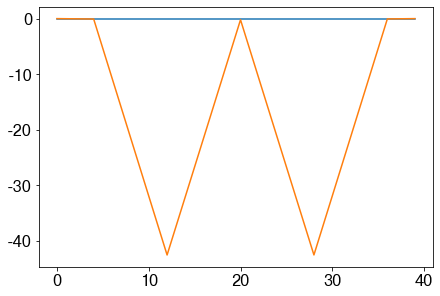

In [ ]:
inverse_heads_hytec = simu_inverse.handlers.results.extract_field_from_grid_res(
    field="head [m]", nx=nx
)

print(inverse_heads_hytec.shape)

plt.plot(inverse_heads_hytec[:, 0, 0, 0])
plt.plot(inverse_heads_hytec[:, 0, 0, -1])

- Plot the darcy velocities (to check that is has been correctly reinitialized)

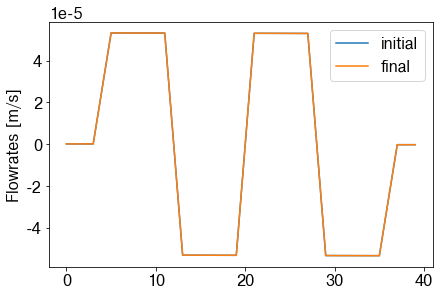

In [ ]:
inverse_darcy_velocities_hytec = (
    simu_inverse.handlers.results.extract_field_from_grid_res(
        field="flowrate [m/s]", nx=nx
    )
)

plt.plot(inverse_darcy_velocities_hytec[:, 0, 0, 0], label="initial")
plt.plot(inverse_darcy_velocities_hytec[:, 0, 0, -1], label="final")
plt.ylabel("Flowrates [m/s]")
plt.legend()

plt.savefig(fig_save_path.joinpath("Darcy velocities check.png"))

- Extract the adjoint variables computed for the first gradient

In [ ]:
print(f"columns = {simu_inverse.handlers.results.optim_res.adjoint_var_columns}")

columns = ['timestep', 'Zones', 'adjoint-variable{T_Cinet} [m]', 'x-distance']


In [ ]:
adj_conc_hytec = simu_inverse.handlers.results.extract_field_from_adj_var_res(
    field="adjoint-variable{T_Cinet} [m]", nx=nx
)
adj_conc_hytec.shape

(40, 1, 1, 301)

### Results comparison

- Compare objective functions

In [ ]:
print(
    "demonstrator 1st obj function = ", executor.rt_solver.inverse_model.list_f_res[0]
)
print("hytec 1st obj function = ", simu_inverse.handlers.results.optim_res.obj_funs[0])

demonstrator 1st obj function =  80490.4308024678
hytec 1st obj function =  20329.0


- The adjoint concentrations should be quite the same both in shape and intensity.

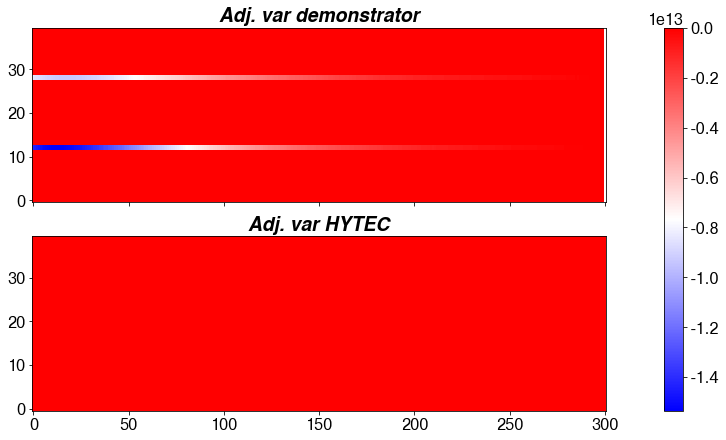

In [ ]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (10, 6)},
    subplots_mosaic_params={
        "fig0": dict(mosaic=[["ax1-1"], ["ax2-1"]], sharey=True, sharex=True)
    },
)

multi_imshow(
    axes=list(plotter.ax_dict.values()),
    fig=plotter.fig,
    data={
        "Adj. var demonstrator": executor.rt_solver.inverse_model.adj_conc[:, 0, :].T,
        "Adj. var HYTEC": adj_conc_hytec[:, 0, 0, :].T,
    },
)

fname = "adjoint_concentrations_dem_vs_hytec_map"
for format in ["png", "pdf"]:
    plotter.fig.savefig(fig_save_path.joinpath(f"{fname}.{format}"), format=format)

- Check the adjoint variables at the observation well

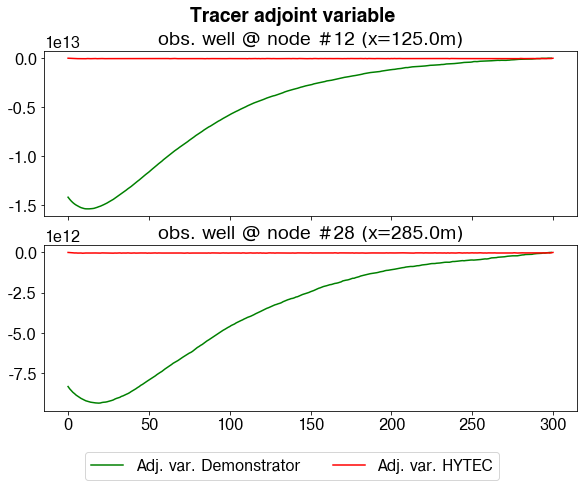

In [ ]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (8, 6)},
    subplots_mosaic_params={
        "fig0": dict(
            mosaic=[["ax1-1"], ["ax2-1"]],
            sharey=False,
            sharex=True,
        )
    },
)

for i, node_id in enumerate(production_locations):
    ax = plotter.get_axis(f"ax{i + 1}-1")
    x = (node_id + 0.5) * model_true.dx
    obs_well_name = f"obs. well @ node #{node_id} (x={x}m)"

    ax.set_title(obs_well_name)
    ax.plot(
        executor.rt_solver.inverse_model.adj_conc[node_id, 0, :],
        label="Adj. var. Demonstrator",
        c="g",
    )
    ax.plot(adj_conc_hytec[node_id, 0, 0, :], label="Adj. var. HYTEC", c="r")

plotter.fig.suptitle("Tracer adjoint variable", fontweight="bold")
plotter.add_fig_legend(ncol=2, bbox_y_shift=-0.02)

fname = "adjoint_concentrations_dem_vs_hytec_1D"
for format in ["png", "pdf"]:
    plotter.fig.savefig(fig_save_path.joinpath(f"{fname}.{format}"), format=format)

- Get the gradients by the adjoint method and finite differences

Finally, plot the gradients comparison.

In [ ]:
# Get the HYTEC  Adj gradient
hytec_fd_gradient = simu_inverse.handlers.results.optim_res.fd_gradients[0]
hytec_adjoint_gradient = simu_inverse.handlers.results.optim_res.adjoint_gradients[0]

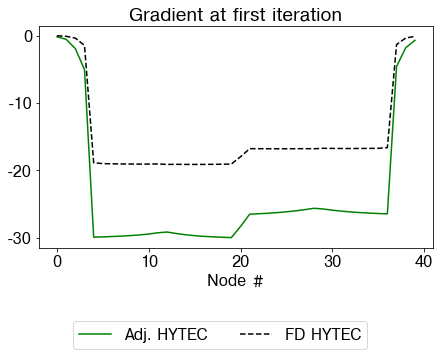

In [ ]:
# Here comes the python code
plotter = NestedGridPlotter()

ax = plotter.get_axis("ax1-1")
# ax.plot(param.archived_adjoint_gradients[0] / 2, label="Adj. Demonstrator", c="b")
# ax.plot(
#     param.archived_fd_gradients[0] / 2, label="FD Demonstrator", c="r", linestyle="--"
# )
ax.plot(hytec_adjoint_gradient["value"], label="Adj. HYTEC", c="g")
ax.plot(hytec_fd_gradient["value"], label="FD HYTEC", c="k", linestyle="--")

ax.set_title("Gradient at first iteration")
ax.set_xlabel("Node #")
plotter.add_fig_legend(ncol=2, bbox_y_shift=-0.1)

fname = "gradient_dem_vs_hytec_adj_vs_df_1d_diffusion"
for format in ["png", "pdf"]:
    plotter.fig.savefig(fig_save_path.joinpath(f"{fname}.{format}"), format=format)